# 销售数据按月汇总与柱状图

本 Notebook 用随机生成的一批销售明细数据，演示「造数 → 按月汇总 → 画柱状图」的完整流程。数据为 2024 全年的销售记录，每条记录包含订单日期、商品类别、金额，随后按自然月汇总销售额并可视化。

In [12]:
import numpy as np
import pandas as pd

# 固定随机种子，保证结果可复现
rng = np.random.default_rng(42)

# 生成 2024 全年共 1000 条销售明细
n = 1000
dates = pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 366, n), unit="D")
categories = rng.choice(["电子", "服饰", "食品", "家居", "图书"], size=n, p=[0.3, 0.25, 0.2, 0.15, 0.1])
amounts = rng.uniform(20, 500, n).round(2)

sales = pd.DataFrame({
    "订单日期": dates,
    "商品类别": categories,
    "金额": amounts,
})

print(f"共 {len(sales)} 条记录，日期范围 {sales['订单日期'].min().date()} ~ {sales['订单日期'].max().date()}")
sales.head(10)

共 1000 条记录，日期范围 2024-01-02 ~ 2024-12-31


,订单日期,商品类别,金额
0,2024-02-02,食品,342.49
1,2024-10-10,家居,481.08
2,2024-08-27,图书,198.04
3,2024-06-09,服饰,224.04
4,2024-06-07,服饰,409.82
5,2024-11-10,家居,262.77
6,2024-02-01,服饰,373.56
7,2024-09-12,家居,240.66
8,2024-03-14,服饰,123.44
9,2024-02-04,电子,377.70


## 按月汇总销售额

将订单日期转成「年月」周期，按月份对金额求和。这里额外给出每月订单量，便于理解柱状图背后的样本分布。

In [13]:
monthly = (
    sales.assign(月份=sales["订单日期"].dt.to_period("M"))
    .groupby("月份", as_index=False)
    .agg(销售额=("金额", "sum"), 订单数=("金额", "size"))
)
monthly["销售额"] = monthly["销售额"].round(2)
monthly

,月份,销售额,订单数
0,2024-01,19092.70,71
1,2024-02,26498.86,105
2,2024-03,19787.91,75
3,2024-04,21372.81,82
4,2024-05,14796.50,57
5,2024-06,24874.25,97
6,2024-07,24585.39,91
7,2024-08,21250.44,86
8,2024-09,21613.88,81
9,2024-10,24210.60,96


## 柱状图可视化

用 matplotlib 画出每月销售额柱状图，并在柱顶标注数值。月份标签转为 `YYYY-MM` 字符串，避免 Period 在坐标轴上显示的格式问题。

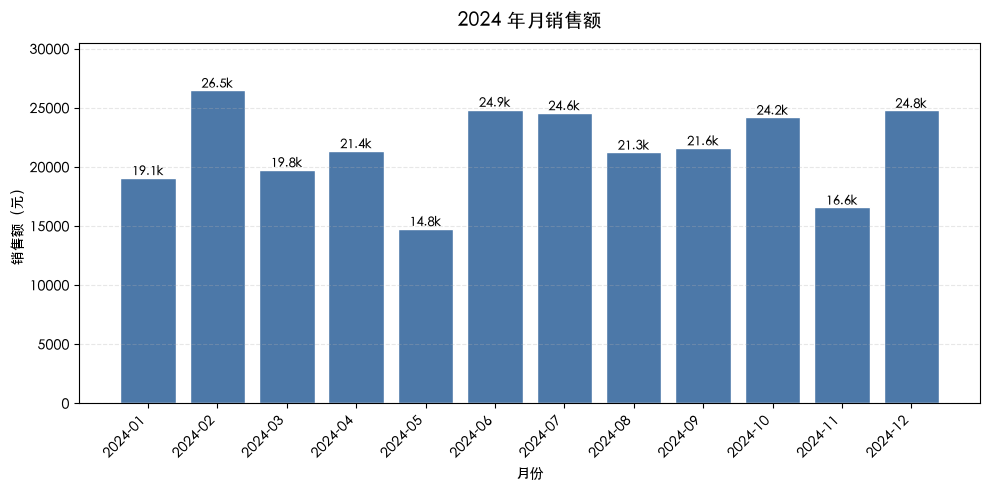

In [14]:
import matplotlib.pyplot as plt

labels = monthly["月份"].astype(str)
values = monthly["销售额"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color="#4C78A8", edgecolor="white")

# 柱顶标注金额（单位：千元）
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{v/1000:.1f}k",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("2024 年月销售额", fontsize=14, pad=12)
ax.set_xlabel("月份")
ax.set_ylabel("销售额（元）")
ax.set_ylim(0, values.max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 小结

本 Notebook 完成了「造数 → 按月汇总 → 画柱状图」：

- 用 `numpy` 固定随机种子生成 2024 全年 1000 条销售明细，字段为订单日期、商品类别、金额；
- 按自然月聚合，得到 12 个月的销售额与订单数。销售额最高的是 2 月（26,498.86 元，105 单），最低的是 5 月（14,796.50 元，57 单）；
- 用 matplotlib 画出月销售额柱状图并在柱顶标注金额。

由于数据是随机生成，金额与订单数在各月间没有明显趋势，仅用于演示汇总与可视化的流程。